# H2 / 6-31G · K=4 NES-VMC —— 实参数 FFNN 拟设版

在原 `H2_631G_8Qbit_K4_Ansatz_A.ipynb` 基础上，把单态拟设由 **Complex FFNN**
换成 **实参数 + 复输出的 FFNN（振幅-相位分离，共享骨干）**。

由此带来的兼容性问题与修复：

1. `jax.grad(machine, argnums=0, holomorphic=True)` 要求输入为复数；实参数会直接报
   `TypeError: grad with holomorphic=True requires inputs with complex dtype`。
2. 修复：对实参数做 Wirtinger 拆分
   `∇logΨ = ∇Re(logΨ) + i·∇Im(logΨ)`；
   力梯度取 `2·Re⟨(trE_L − ⟨trE_L⟩)(∇logΨ)*⟩`，
   几何张量（QGT）度量取 `Re(S)`，自然梯度求解实数系统 `Re(S)⁻¹ g`
   （不能复数求解后丢虚部）。
3. 梯度 / QGT 的实参数版本在本 notebook 内重新实现，**不改动共享模块**
   `NES_VMC_tool.py`，不影响其它实验。


In [1]:
import logging
import os
import time
import pickle
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import optax
import numpy as np
from jax.flatten_util import ravel_pytree

from NES_VMC_V1 import (
    create_single_machine_gauge_fixed,
    Ham_Psi_scaled,
    NESFermionHopRule,
    flatten_batched_pytree,
)
from NES_VMC_tool import (
    create_gauge_reset_total_machines,
    NES_loss_energy_stable_gauge,
    _masked_mean_batch,
    make_gauge_fn,
)
from H2_6_31G_8Qbit_K2 import SINGLE_SIZE, ha, hi_ext, ext_edges, K, hi, E_fcis, Hatree_Fock

jax.config.update("jax_enable_x64", True)


∣NK⟩ Tip: Avoid LocalOperator with have N-body operators (N>4). PauliStrings is ok.

H2 分子基本信息
HF energy = -0.99749729 Ha
Total electrons = (1, 1)
Total basis functions = 4
H₂ FCI 基准能量
E0 = -1.05434745 Ha  |  激发能: 0.0000 eV
E1 = -0.95790573 Ha  |  激发能: 2.6243 eV
E2 = -0.66895227 Ha  |  激发能: 10.4871 eV
E3 = -0.55140192 Ha  |  激发能: 13.6859 eV
E4 = -0.02803278 Ha  |  激发能: 27.9275 eV
E5 = -0.01450343 Ha  |  激发能: 28.2956 eV
E6 = -0.00518297 Ha  |  激发能: 28.5492 eV
E7 = 0.02397075 Ha  |  激发能: 29.3425 eV
E8 = 0.23432390 Ha  |  激发能: 35.0666 eV
E9 = 0.25720575 Ha  |  激发能: 35.6892 eV
E10 = 0.49958128 Ha  |  激发能: 42.2846 eV
E11 = 0.50024484 Ha  |  激发能: 42.3026 eV

HF reference state: [0 0 0 1 0 0 0 1]
single_edges: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


## 1. Ansatz 定义（实参数 + 复输出）

In [2]:
# ===================== Ansatz：振幅-相位分离（共享骨干，实参数 + 复输出） =====================
class SingleStateAnsatz_SharedBackbone(nnx.Module):
    def __init__(self, n_spin_orbitals: int, hidden_dim: int = 16, *, rngs: nnx.Rngs):
        super().__init__()
        self.n_so = n_spin_orbitals
        # 注意：param_dtype=float -> 实数参数（网络输出再组合成复数）
        self.backbone1 = nnx.Linear(n_spin_orbitals, hidden_dim, rngs=rngs, param_dtype=float)
        self.backbone2 = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs, param_dtype=float)
        self.head_logA = nnx.Linear(hidden_dim, 1, rngs=rngs, param_dtype=float)
        self.head_phi = nnx.Linear(hidden_dim, 1, rngs=rngs, param_dtype=float)

    def __call__(self, x: jax.Array) -> jax.Array:
        h = nnx.tanh(self.backbone1(x))
        h = nnx.tanh(self.backbone2(h))
        logA = jnp.squeeze(self.head_logA(h))
        phi = jnp.squeeze(self.head_phi(h))
        # 振幅-相位分离：logψ = logA + i·φ
        return logA + 1j * phi


class NESTotalAnsatz_stable(nnx.Module):
    """NES 总拟设：K 个「实参数 + 复输出」单态拟设组成的行列式波函数。"""

    def __init__(self, n_spin_orbitals: int, n_states: int = 2, hidden_dim: int = 8, *, rngs: nnx.Rngs):
        super().__init__()
        self.K = n_states
        self.n_spin = n_spin_orbitals

        self.single_ansatz_list = nnx.List()
        key = rngs.params()

        for _ in range(n_states):
            key, sub_key = jax.random.split(key)
            sub_rngs = nnx.Rngs(params=sub_key)
            ansatz = SingleStateAnsatz_SharedBackbone(n_spin_orbitals, hidden_dim, rngs=sub_rngs)
            self.single_ansatz_list.append(ansatz)

    def __call__(self, x: jax.Array):
        def _forward_single(x_single):
            x_single = x_single.reshape(self.K, self.n_spin)

            # 用 complex128 承接复输出，避免 complex128->complex64 的隐式降精度 scatter
            L = jnp.zeros((self.K, self.K), dtype=jnp.complex128)

            for i in range(self.K):
                for j in range(self.K):
                    L = L.at[i, j].set(self.single_ansatz_list[j](x_single[i]))

            shift = jax.lax.stop_gradient(jnp.max(jnp.real(L)))
            L_stable = L - shift
            Psi_stable = jnp.exp(L_stable)

            sign, log_abs_det = jnp.linalg.slogdet(Psi_stable)
            log_Psi_stable = log_abs_det + 1j * jnp.angle(sign)

            return log_Psi_stable, L_stable, shift

        if x.ndim == 2 and x.shape[-1] == self.n_spin:
            return _forward_single(x)

        elif x.ndim == 2 and x.shape[-1] == self.n_spin * self.K:
            x = x.reshape(-1, self.K, self.n_spin)
            return jax.vmap(_forward_single)(x)

        elif x.ndim == 3:
            x = x.reshape(-1, self.K, self.n_spin)
            return jax.vmap(_forward_single)(x)

        elif x.ndim == 1:
            x = x.reshape(self.K, self.n_spin)
            return _forward_single(x)

        else:
            raise ValueError(f"不支持的输入形状: {x.shape}")


## 2. 实参数梯度 / QGT 兼容层

原复参数版本使用 `holomorphic=True` 求导；这里改成对实参数的 Re / Im 分别求导再组合。


In [3]:
# ============================================================
# 实参数 / 复输出 logΨ 的梯度兼容层
# ------------------------------------------------------------
# 原 Complex FFNN 参数是复数，直接可用
#     jax.grad(machine, argnums=0, holomorphic=True)
# 现在换成「实数参数 + 复数输出」，holomorphic=True 要求输入 dtype 为复数，直接报错。
# 处理办法（Wirtinger 拆分）：对实参数分别求 Re / Im 两个实值函数的梯度，再组合
#     ∇logΨ(θ) = ∇Re(logΨ) + i·∇Im(logΨ)
# 由此（实参数、复波函数）：
#   力梯度   ∇⟨L⟩ = 2·Re⟨ (tr E_L − ⟨tr E_L⟩) (∇logΨ)* ⟩
#   QGT      度量取 Re(S)，S_ij = ⟨(∂_i logΨ)* (∂_j logΨ)⟩
# ============================================================

def _grad_logpsi_real_single(total_machine, params, x_single, g):
    """单样本梯度（实参数、复输出）：∇logΨ = ∇Re + i·∇Im。"""
    re_grad = jax.grad(lambda p: jnp.real(total_machine(p, x_single, g)))(params)
    im_grad = jax.grad(lambda p: jnp.imag(total_machine(p, x_single, g)))(params)
    return jax.tree_util.tree_map(lambda r, i: r + 1j * i, re_grad, im_grad)


def nes_vmc_gradient_stable_gauge_real(
    ha,
    total_matrix_machine,
    total_max_machine,
    total_machine,
    single_machine_list,
    total_params,
    x_batch,
    g,
    min_valid_ratio: float = 0.25,
    return_aux: bool = False,
):
    """实参数版 NES-VMC 梯度。结构对齐 nes_vmc_gradient_stable_gauge，
    仅将 ∇logΨ 换成 Wirtinger 拆分，并对实参数取实部 + 因子 2。"""
    loss_batch, E_L_batch, loss_aux = NES_loss_energy_stable_gauge(
        ha=ha,
        total_matrix_machine=total_matrix_machine,
        total_max_machine=total_max_machine,
        single_machine_list=single_machine_list,
        total_params=total_params,
        x=x_batch,
        g=g,
        return_aux=True,
    )

    valid = jax.lax.stop_gradient(loss_aux["valid"])
    batch_size = x_batch.shape[0]
    n_valid = jnp.sum(valid.astype(jnp.float32))
    valid_ratio = n_valid / batch_size

    E_L_mean = _masked_mean_batch(E_L_batch, valid)

    E_L_safe = jnp.where(jnp.isfinite(E_L_batch), E_L_batch, 0.0)
    E_L_centered = E_L_safe - E_L_mean

    tr_centered = jnp.trace(E_L_centered, axis1=-2, axis2=-1)
    tr_centered = jnp.where(valid, tr_centered, 0.0)

    # 每个样本的 ∇logΨ（复 pytree，batch 维在最前）
    dlogPsi_batch = jax.vmap(
        lambda x: _grad_logpsi_real_single(total_machine, total_params, x, g)
    )(x_batch)

    def weight_and_masked_mean(grad_component):
        grad_safe = jnp.where(jnp.isfinite(grad_component), grad_component, 0.0)
        weights = tr_centered.reshape((-1,) + (1,) * (grad_component.ndim - 1))
        valid_f = valid.astype(jnp.float32).reshape((-1,) + (1,) * (grad_component.ndim - 1))
        weighted = weights * jnp.conj(grad_safe) * valid_f
        denom = jnp.maximum(n_valid, 1.0)
        # 实参数：取实部，因子 2
        return 2.0 * jnp.real(jnp.sum(weighted, axis=0) / denom)

    grad = jax.tree.map(weight_and_masked_mean, dlogPsi_batch)

    loss_mean = _masked_mean_batch(loss_batch, valid)

    grad_flat, _ = ravel_pytree(grad)
    grad_finite = jnp.all(jnp.isfinite(grad_flat))
    loss_finite = jnp.isfinite(loss_mean)
    enough_valid = valid_ratio >= min_valid_ratio

    aux = {
        "valid": valid,
        "n_valid": n_valid,
        "valid_ratio": valid_ratio,
        "grad_finite": grad_finite,
        "loss_finite": loss_finite,
        "enough_valid": enough_valid,
        "should_skip": ~(grad_finite & loss_finite & enough_valid),
        "loss_aux": loss_aux,
    }

    if return_aux:
        return grad, loss_mean, E_L_mean, aux

    return grad, loss_mean, E_L_mean


def make_grad_fn_gauge_real(ha, total_matrix_machine, total_max_machine, total_machine, single_machine_list):
    @jax.jit
    def grad_fn(total_params, x_batch, g):
        return nes_vmc_gradient_stable_gauge_real(
            ha=ha,
            total_matrix_machine=total_matrix_machine,
            total_max_machine=total_max_machine,
            total_machine=total_machine,
            single_machine_list=single_machine_list,
            total_params=total_params,
            x_batch=x_batch,
            g=g,
            return_aux=True,
        )

    return grad_fn


def make_qgt_fn_gauge_real(machine):
    """实参数版 QGT：∇logΨ 用 Wirtinger 拆分，度量取 Re(S)。"""

    @jax.jit
    def qgt_fn(params, sigma, diag_shift, g):
        n_samples = sigma.shape[0]

        grad_tree_batch = jax.vmap(
            lambda s: _grad_logpsi_real_single(machine, params, s, g)
        )(sigma)

        O = flatten_batched_pytree(grad_tree_batch, n_samples)   # (N, P) 复数

        O_mean = jnp.mean(O, axis=0, keepdims=True)
        O_centered = O - O_mean

        S = (jnp.conj(O_centered).T @ O_centered) / n_samples
        S = 0.5 * (S + jnp.conj(S.T))

        S_real = jnp.real(S)                                  # 实参数度量
        I = jnp.eye(S_real.shape[0], dtype=S_real.dtype)
        return S_real + diag_shift * I

    return qgt_fn


In [4]:
# ====================== 日志配置 ======================
time_str = time.strftime("%y-%m-%d-%H-%M")
logger = logging.getLogger("NES_VMC_K4_gauge_reset_realFFNN")
logger.setLevel(logging.INFO)
logger.propagate = False
logger.handlers.clear()
simple_formatter = logging.Formatter("%(asctime)s %(message)s", datefmt="%y-%d-%H-%M")

os.makedirs("./日志", exist_ok=True)
log_path = f"./日志/{time_str}_nes_vmc_K4_H2_6-31G_gauge_reset_realFFNN.log"
file_handler = logging.FileHandler(log_path, mode="w", encoding="utf-8")
file_handler.setFormatter(simple_formatter)
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(simple_formatter)
logger.addHandler(console_handler)

# ====================== 超参配置 ======================
N_CHAINS = 16
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 20
N_ITER = 300
Natural_Grad = True
clip_norm = 20.0
per_param_clip = 0.5
lr = 0.1
qgt_diag_shift = 0.1
RESET_PERIOD = 10
SAVE_INTERVAL = 20
HISTORY_FILE = f"./data/{time_str}_history_natural_gradient_H2_molecule_K4_realFFNN.pkl"
os.makedirs("./data", exist_ok=True)

# ====================== 模型与采样器 ======================
total_ansatz = NESTotalAnsatz_stable(
    n_spin_orbitals=SINGLE_SIZE,
    n_states=K,
    hidden_dim=SINGLE_SIZE + K,
    rngs=nnx.Rngs(11),
)

g_current = jnp.zeros(K, dtype=jnp.complex128)   # 全局列规范 g，非训练参数，动态传入 jit

(
    total_machine,
    total_matrix_machine,
    total_max_machine,
    total_matrix_machine_raw,
    total_graphdef,
    total_params,
) = create_gauge_reset_total_machines(total_ansatz, Hatree_Fock)

single_machine_list = [
    create_single_machine_gauge_fixed(ansatz, Hatree_Fock)[0]
    for ansatz in total_ansatz.single_ansatz_list
]

# 关键替换：使用实参数版梯度 / QGT（原 make_grad_fn_gauge / make_qgt_fn_gauge 依赖复数参数）
grad_fn = make_grad_fn_gauge_real(
    ha,
    total_matrix_machine,
    total_max_machine,
    total_machine,
    single_machine_list,
)
qgt_fn = make_qgt_fn_gauge_real(total_machine)

gauge_fn, col_mean_fn = make_gauge_fn(total_ansatz, Hatree_Fock)

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=N_CHAINS,
    sweep_size=SWEEP_SIZE,
)

# FCI 精确参考能量
exact_eigvals = E_fcis

# ====================== 优化器 ======================
optimizer = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.sgd(learning_rate=lr),
)
opt_state = optimizer.init(total_params)

sampler_rng = jax.random.PRNGKey(21)


def sample_machine(params, sigma):
    """采样只需要 |Ψ|² 的转移率，全局列规范 g 是常数平移，不影响 ratio。"""
    return total_machine(params, sigma, g_current)


sampler_state = nes_sampler.init_state(sample_machine, total_params, sampler_rng)

# ====================== 训练循环 ======================
logger.info("\n" + "=" * 60)
logger.info("开始多链 NES-VMC 训练 | 实参数 FFNN | 双侧一致列规范 + 周期性 gauge reset")
logger.info(f"""超参数配置:\n\
N_CHAINS ={N_CHAINS}\n\
N_SAMPLES_PER_CHAIN ={N_SAMPLES_PER_CHAIN}\n\
SWEEP_SIZE = {SWEEP_SIZE}\n\
N_ITER = {N_ITER}\n\
Natural_Grad = {Natural_Grad}\n\
clip_norm = {clip_norm}\n\
per_param_clip = {per_param_clip}\n\
lr = {lr}\n\
qgt_diag_shift = {qgt_diag_shift}\n\
RESET_PERIOD = {RESET_PERIOD}\n\
SAVE_INTERVAL = {SAVE_INTERVAL}\
""")

logger.info("=" * 60)
logger.info(
    f"精确CAS基准：基态={exact_eigvals[0]:.8f} Ha | 1激发={exact_eigvals[1]:.8f} Ha"
    f"|2激发={exact_eigvals[2]:.8f} Ha|3激发={exact_eigvals[3]:.8f} Ha|"
)
logger.info(f"理论 Loss 上限：{sum(exact_eigvals[0:K]):.8f} ")
logger.info(f"超参：clip_norm={clip_norm}, per_param_clip={per_param_clip}, lr={lr}, QGT diag_shift={qgt_diag_shift}, RESET_PERIOD={RESET_PERIOD}")

import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt

loss_history = []
logpsi_history = []
steps_history = []
logpsi_mean_history = []
logpsi_min_history = []
logpsi_max_history = []
grad_norm_raw_history = []
grad_norm_per_param_history = []
grad_norm_nat_history = []
E_L_real_history = []
E_L_imag_history = []
params_history = []
Energy_levels_history = []
samples_history = []
gaugue_reset_history = []


start_time = time.time()

# ====================== 初始化/加载 pickle 历史文件 ======================
first_step = None
last_step = None
if os.path.exists(HISTORY_FILE):
    try:
        with open(HISTORY_FILE, "rb") as f:
            history = pickle.load(f)
        if history.get("steps"):
            last_step = int(history["steps"][-1])
            first_step = int(history["steps"][0])
            logger.info(f"检测到已有历史文件，上次保存 step={last_step}，将从 step={last_step + 1} 继续")
        else:
            logger.info("检测到历史文件但为空，将从头开始")
    except Exception as e:
        logger.warning(f"读取历史文件失败（可能损坏），将覆盖写入: {e}")
# ====================== 初始化结束 ======================


26-02-14-12 
26-02-14-12 开始多链 NES-VMC 训练 | 实参数 FFNN | 双侧一致列规范 + 周期性 gauge reset
26-02-14-12 超参数配置:
N_CHAINS =16
N_SAMPLES_PER_CHAIN =200
SWEEP_SIZE = 20
N_ITER = 300
Natural_Grad = True
clip_norm = 20.0
per_param_clip = 0.5
lr = 0.1
qgt_diag_shift = 0.1
RESET_PERIOD = 10
SAVE_INTERVAL = 20
26-02-14-12 ============================================================
26-02-14-12 精确CAS基准：基态=-1.05434745 Ha | 1激发=-0.95790573 Ha|2激发=-0.66895227 Ha|3激发=-0.55140192 Ha|
26-02-14-12 理论 Loss 上限：-2.01225318 
26-02-14-12 超参：clip_norm=20.0, per_param_clip=0.5, lr=0.1, QGT diag_shift=0.1, RESET_PERIOD=10


In [5]:
for step in range(N_ITER):
    params_history.append(total_params)
    # 1. 采样
    samples_raw, sampler_state = nes_sampler.sample(
        machine=sample_machine,
        parameters=total_params,
        state=sampler_state,
        chain_length=N_SAMPLES_PER_CHAIN,
    )
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, SINGLE_SIZE)

    # 2. 梯度与损失（实参数版）
    grad_raw, loss_mean, E_L_mean, aux = grad_fn(total_params, x_batch, g_current)

    grad_raw_flat, unravel_fn = ravel_pytree(grad_raw)
    grad_norm_raw = jnp.linalg.norm(grad_raw_flat)
    n_params = grad_raw_flat.size
    grad_norm_per_param = grad_norm_raw / jnp.sqrt(n_params)

    # 【裁剪】per-param 梯度范数超过上限时按比例整体缩放（发生在计算 QGT 之前）
    if float(grad_norm_per_param) > per_param_clip:
        grad_scale = per_param_clip / float(grad_norm_per_param)
        grad_raw_flat = grad_raw_flat * grad_scale
        grad_raw = unravel_fn(grad_raw_flat)
        grad_norm_raw = jnp.linalg.norm(grad_raw_flat)
        grad_norm_per_param = grad_norm_raw / jnp.sqrt(n_params)
        logger.info(f"【Step {step}】per-param 梯度范数超限，已裁剪：scale={grad_scale:.4f} | 裁剪后 per_param={float(grad_norm_per_param):.4f}")

    grad_update = grad_raw

    has_nan = bool(jnp.any(jnp.isnan(grad_raw_flat)))
    if has_nan or grad_norm_raw > 5000.0:
        logger.warning(f"【Step {step} 告警】梯度异常！nan={has_nan}, raw_grad_norm={grad_norm_raw:.2f}")

    # 3. QGT 自然梯度（实对称系统，直接实数求解）
    if Natural_Grad:
        qgt_reg_mat = qgt_fn(total_params, x_batch, qgt_diag_shift, g_current)
        ng_flat = jnp.linalg.solve(qgt_reg_mat, grad_raw_flat)
        grad_update = unravel_fn(ng_flat)
        grad_norm_natural = jnp.linalg.norm(ng_flat)
    else:
        grad_norm_natural = grad_norm_raw

    # 4. 优化器内部完成梯度裁剪 + SGD 更新
    updates, opt_state = optimizer.update(grad_update, opt_state, total_params)
    total_params = optax.apply_updates(total_params, updates)

    grad_norm_clipped = min(float(grad_norm_natural), clip_norm)

    # 5. 能量监控：E_L 矩阵本征值
    eig_vals, _ = jnp.linalg.eig(E_L_mean)
    eig_vals = eig_vals[jnp.argsort(eig_vals.real)]

    # 6. 波函数与 Ψ 矩阵条件数监控
    log_Psi_batch = total_machine(total_params, x_batch, g_current)
    x_single = x_batch[0:1, ...]
    psi_mat = total_matrix_machine(total_params, x_single, g_current)[0]
    psi_cond = jnp.linalg.cond(psi_mat)

    gauge_now = float(jnp.real(gauge_fn(total_params, x_batch)))
    g_abs = float(jnp.linalg.norm(g_current))

    # 7. 日志
    logger.info(f"[Step {step:3d}] logΨ: mean={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")
    logger.info(f"梯度监控 | raw={grad_norm_raw:.4f} | per_param={grad_norm_per_param:.4f} |  natural={grad_norm_natural:.4f} | clipped={grad_norm_clipped:.4f}(上限{clip_norm})")
    logger.info(f"原始规范坐标 G(Re Σrow_mean) = {gauge_now:+.4f} | 累计|g| = {g_abs:.4f}")
    logger.info(f"Ψ矩阵条件数 cond(Ψ) = {psi_cond:.2e}")
    logger.info(
        f"Loss={loss_mean:.6f} | E0={eig_vals[0]:.8f} | E1={eig_vals[1]:.8f}"
        f"|E2={eig_vals[2]:.8f}|E3={eig_vals[3]:.8f}"
    )
    logger.info("#-----------------------------------------#")

    loss_history.append(float(jnp.real(loss_mean)))
    logpsi_history.append(float(jnp.real(log_Psi_batch.mean())))
    steps_history.append(step)

    logpsi_mean_history.append(float(jnp.real(log_Psi_batch.mean())))
    logpsi_min_history.append(float(jnp.real(log_Psi_batch.min())))
    logpsi_max_history.append(float(jnp.real(log_Psi_batch.max())))
    grad_norm_raw_history.append(float(grad_norm_raw))
    grad_norm_nat_history.append(float(grad_norm_natural))
    grad_norm_per_param_history.append(float(grad_norm_per_param))
    E_L_real_history.append(float(jnp.real(jnp.trace(E_L_mean))))
    E_L_imag_history.append(float(jnp.imag(jnp.trace(E_L_mean))))
    Energy_levels_history.append(eig_vals[:K])
    samples_history.append(samples)

    # 每 SAVE_INTERVAL 步保存/追加一次 pickle
    if (step + 1) % SAVE_INTERVAL == 0:
        history = {
            "steps": [int(s) for s in steps_history],
            "logpsi_mean": logpsi_mean_history,
            "logpsi_min": logpsi_min_history,
            "logpsi_max": logpsi_max_history,
            "grad_norm_raw": grad_norm_raw_history,
            "grad_norm_natural": grad_norm_nat_history,
            "grad_norm_per_param": grad_norm_per_param_history,
            "E_L_real": E_L_real_history,
            "E_L_imag": E_L_imag_history,
            "loss": loss_history,
            "first_step": first_step if first_step is not None else 0,
            "save_interval": SAVE_INTERVAL,
            "Energy_levels": Energy_levels_history,
            "params": params_history,
        }

        with open(HISTORY_FILE, "wb") as f:
            pickle.dump(history, f)
        logger.info(f"[保存] Step {step} → pickle 文件已更新 ({len(steps_history)} 条记录)")

    # 8. 周期性 gauge reset：把 raw L 的列均值吸收进全局 g（物理不变）
    if (step + 1) % RESET_PERIOD == 0:
        new_col_mean = col_mean_fn(total_params, x_batch)
        g_current = new_col_mean
        absorbed = float(jnp.sum(jnp.real(new_col_mean)))
        logger.info(
            f"[GaugeReset@{step + 1}] 吸收 Δg = Σ Re(col_mean) = {absorbed:+.4f} "
            f"| 新|g| = {float(jnp.linalg.norm(g_current)):.4f}"
        )

end_time = time.time()
logger.info(f"训练耗时：{end_time - start_time:.2f} 秒")
logger.info("\n" + "=" * 60)
logger.info("训练完成!")
logger.info("=" * 60)

# 训练结束后最后一次写入，确保数据完整
history = {
    "steps": [int(s) for s in steps_history],
    "logpsi_mean": logpsi_mean_history,
    "logpsi_min": logpsi_min_history,
    "logpsi_max": logpsi_max_history,
    "grad_norm_raw": grad_norm_raw_history,
    "grad_norm_natural": grad_norm_nat_history,
    "grad_norm_per_param": grad_norm_per_param_history,
    "E_L_real": E_L_real_history,
    "E_L_imag": E_L_imag_history,
    "loss": loss_history,
    "first_step": first_step if first_step is not None else 0,
    "save_interval": SAVE_INTERVAL,
    "Energy_levels": Energy_levels_history,
    "params": params_history,
    "samples": samples_history,
}
with open(HISTORY_FILE, "wb") as f:
    pickle.dump(history, f)
logger.info(f"[保存] 训练结束，pickle 最终写入 {len(steps_history)} 条记录 → {HISTORY_FILE}")


/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(
26-02-14-12 [Step   0] logΨ: mean=1.032+0.131j | min=-0.941-2.254j | max=1.777+2.874j
26-02-14-12 梯度监控 | raw=1.5138 | per_param=0.0718 |  natural=2.4143 | clipped=2.4143(上限20.0)
26-02-14-12 原始规范坐标 G(Re Σrow_mean) = +0.8879 | 累计|g| = 0.0000
26-02-14-12 Ψ矩阵条件数 cond(Ψ) = 1.99e+00
26-02-14-12 Loss=0.609501 | E0=0.12520759-0.00061008j | E1=0.48429366+0.00223616j|E2=0.48429366+0.00223616j|E3=0.48429366+0.00223616j
26-02-14-12 #-----------------------------------------#
26-02-14-12 [Step   1] logΨ: mean=1.429+0.122j | min=-0.913+1.548j | max=2.161+3.068j
26-02-14-12 梯度监控 | raw=1.6050 | per_param=0.0762 |  natural=2.4882 | clipped=2.4882(上限20.0)
26-02-14-12 原始规范坐标 G(Re Σrow_mean) =

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


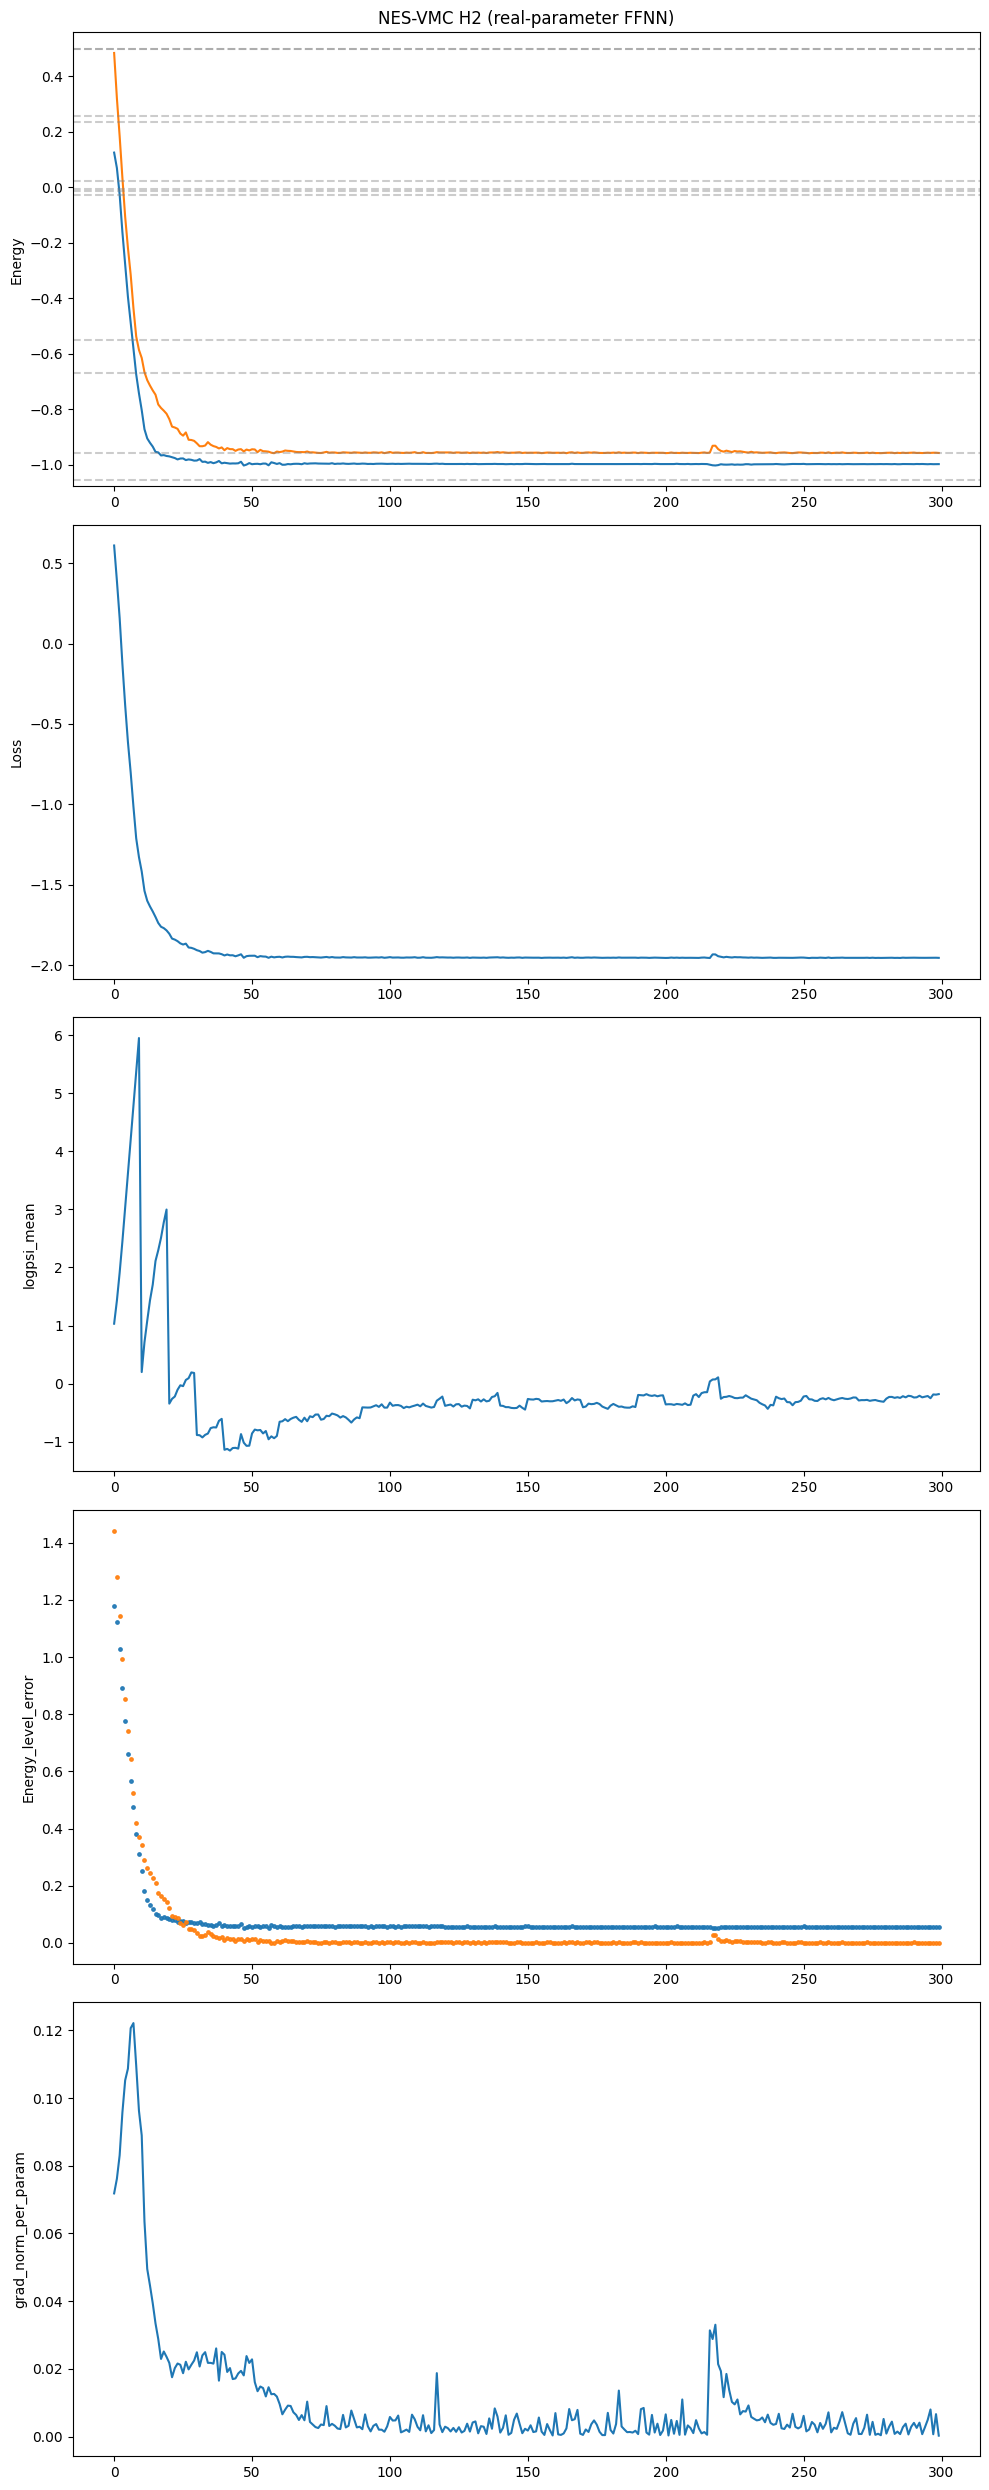

In [6]:
energy_level_error = []
for i in range(len(history["steps"])):
    row = [abs(history["Energy_levels"][i][j] - E_fcis[j]) for j in range(K)]
    energy_level_error.append(np.array(row))
energy_level_error = np.array(energy_level_error)

fig, axs = plt.subplots(5, 1, figsize=(10, 25))

axs[0].plot(history["steps"], history["Energy_levels"])
for i in E_fcis:
    axs[0].axhline(i, color="gray", ls="--", alpha=0.4)
axs[0].set_ylabel("Energy")
axs[0].set_title("NES-VMC H2 (real-parameter FFNN)")

axs[1].plot(history["steps"], history["loss"])
axs[1].set_ylabel("Loss")

axs[2].plot(history["steps"], history["logpsi_mean"])
axs[2].set_ylabel("logpsi_mean")

for i in range(K):
    axs[3].scatter(history["steps"], np.array(history["Energy_levels"])[:, i] - E_fcis[i], s=6, alpha=0.9)
axs[3].set_ylabel("Energy_level_error")
#axs[3].set_ylim(0.0,0.01)

axs[4].plot(history["steps"], history["grad_norm_per_param"])
axs[4].set_ylabel("grad_norm_per_param")

fig.tight_layout()
fig.savefig("H2_631G_8Qbit_K4_Ansatz_A_RealFFNN.png", dpi=150)
plt.show()
